In [6]:
import pandas as pd
import numpy as np
import sys
import os
import random
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

#行の表示数の上限を撤廃
pd.set_option('display.max_rows', None)

#列の表示数の上限を撤廃
pd.set_option('display.max_columns', None)

In [6]:
pwd

'/work'

In [4]:
train_df = pd.read_csv("/work/Real_estate/train/train.csv")
test_df = pd.read_csv("/work/Real_estate/test/test.csv")

<ipython-input-4-4893a7cd3112>:1: DtypeWarning: Columns (63) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv("/work/Real_estate/train/train.csv")
<ipython-input-4-4893a7cd3112>:2: DtypeWarning: Columns (46,55,56,63,146) have mixed types. Specify dtype option on import or set low_memory=False.
  test_df = pd.read_csv("/work/Real_estate/test/test.csv")


In [7]:
train_df.head()

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,target_ym,money_room,building_id,building_status,building_create_date,building_modify_date,building_type,building_name,building_name_ruby,homes_building_name,homes_building_name_ruby,unit_count,full_address,lon,lat,building_structure,total_floor_area,building_area,floor_count,basement_floor_count,year_built,building_land_area,land_area_all,unit_area_min,unit_area_max,building_land_chimoku,land_youto,land_toshi,land_chisei,land_area_kind,land_setback_flg,land_setback,land_kenpei,land_youseki,land_road_cond,land_seigen,building_area_kind,management_form,management_association_flg,reform_exterior,reform_exterior_other,reform_exterior_date,reform_common_area,reform_common_area_date,building_tag_id,unit_id,unit_name,name_ruby,room_floor,balcony_area,dwelling_unit_window_angle,room_count,unit_area,floor_plan_code,reform_date,reform_place,reform_place_other,reform_wet_area,reform_wet_area_other,reform_wet_area_date,reform_interior,reform_interior_other,reform_interior_date,reform_etc,renovation_date,renovation_etc,unit_tag_id,bukken_id,snapshot_create_date,new_date,snapshot_modify_date,timelimit_date,bukken_type,flg_investment,empty_number,empty_contents,post1,post2,addr1_1,addr1_2,addr2_name,addr3_name,nl,el,rosen_name1,eki_name1,bus_stop1,bus_time1,walk_distance1,rosen_name2,eki_name2,bus_stop2,bus_time2,walk_distance2,traffic_other,traffic_car,snapshot_land_area,snapshot_land_shidou,land_shidou_a,land_shidou_b,land_mochibun_a,land_mochibun_b,house_area,flg_new,house_kanrinin,room_kaisuu,snapshot_window_angle,madori_number_all,madori_kind_all,money_kyoueki,money_kyoueki_tax,money_rimawari_now,money_shuuzen,money_shuuzenkikin,money_sonota_str1,money_sonota1,money_sonota_str2,money_sonota2,money_sonota_str3,money_sonota3,parking_money,parking_money_tax,parking_kubun,parking_distance,parking_number,parking_memo,genkyo_code,usable_status,usable_date,school_ele_name,school_ele_distance,school_ele_code,school_jun_name,school_jun_distance,school_jun_code,convenience_distance,super_distance,hospital_distance,park_distance,drugstore_distance,bank_distance,shopping_street_distance,est_other_name,est_other_distance,statuses,parking_keiyaku,money_hoshou_company,free_rent_duration,free_rent_gen_timing
0,201901,13980000,206271,1,2014-06-27 21:09:41,2019-01-24 00:10:08,4,NaN,NaN,桑名市東正和台7丁目10-11,NaN,NaN,三重県桑名市東正和台7丁目10-11,136.637467,35.047688,1.0,106.820000,NaN,2.0,NaN,199204.0,188.490005,188.490005,NaN,NaN,1.0,1.0,1.0,NaN,1.0,NaN,NaN,50.0,80.0,NaN,NaN,1.0,NaN,NaN,NaN,外壁塗装,201807.0,NaN,NaN,210202/210301/210101,262186,NaN,NaN,NaN,NaN,NaN,4.0,106.820000,450.0,NaN,NaN,NaN,1/2/3/4,NaN,201807.0,NaN,畳表替え,201807.0,NaN,NaN,NaN,310501/220701/220601/230401,360840,2018-10-30 00:00:00,2018-10-30 00:00:00,2019-01-22 13:20:11,2019-02-05 00:00:00,1202,NaN,1.0,NaN,511.0,932.0,24,205,東正和台7丁目,NaN,126159934.0,491905398.0,三岐鉄道北勢線,在良,NaN,NaN,1840.0,NaN,NaN,NaN,NaN,NaN,コミュニティバス「東正和台」停より約 500m,NaN,188.49,NaN,NaN,NaN,NaN,NaN,106.82,0.0,NaN,NaN,NaN,4,50,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,1.0,NaN,2.0,NaN,2.0,1,NaN,桑部小学校,2000.0,NaN,正和中学校,2000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,210101/220701/220601/230401/310501/210301/210202,NaN,NaN,NaN,NaN
1,201901,24480000,83315,1,2014-06-27 21:09:43,2019-04-03 00:10:08,4,NaN,NaN,桑名市松ノ木5丁目,NaN,1.0,三重県桑名市松ノ木5丁目14-8,136.639936,35.074625,10.0,NaN,NaN,2.0,NaN,198108.0,290.519989,NaN,NaN,NaN,NaN,1.0,1.0,1.0,2.0,1.0,1.2,50.0,80.0,1.0,NaN,NaN,NaN,NaN,2,外壁塗装,201706.0,NaN,NaN,330501/210301/210101/210201,35726,NaN,NaN,NaN,NaN,5.0,4.0,134.039993,450.0,NaN,NaN,NaN,1/2/3/4,キッチン・ユニットバス・洗面化粧台コーティング/トイレ新品,201706.0,2/4,NaN,201706.0,NaN,2017-06-01,外装外壁塗装 内装システムキッチン新品/お風呂新品/洗面台新品/トイレ新品/フローリング上張...,260201/260301/220801/230601/260101/230101/2203...,267022,2018-10-30 00:00:00,2018-10-30 00:00:00,2019-01-30 15:15:49,2019-02-13 00:00:00,1202,NaN,NaN,NaN,511.0,902.0,24,205,松ノ木5丁目,NaN,126256831.0,491914000.0,三岐鉄道北勢線,星川,NaN,NaN,1920.0,NaN,NaN,NaN,NaN,NaN,コミュニティバス「法務局前」停より約400m,NaN,290.52,NaN,NaN,NaN,NaN,NaN,134.04,0.0,NaN,NaN,NaN,4,50,NaN,3

In [22]:
def missing_data(data):
    total = data.isnull().sum()
    percent = (data.isnull().sum()/data.isnull().count()*100)
    tt = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
    types = []
    for col in data.columns:
        dtype = str(data[col].dtype)
        types.append(dtype)
    tt['Types'] = types
    return(np.transpose(tt))

In [10]:
def calculate_age_months(row):
    try:
        t_y, t_m = divmod(int(row['target_ym']), 100)
        b_y, b_m = divmod(int(row['year_built']), 100)
        return (t_y - b_y) * 12 + (t_m - b_m)
    except:
        return np.nan

In [25]:
def most_frequent_values(data):
    total = data.count()
    tt = pd.DataFrame(total)
    tt.columns = ['Total']
    items = []
    vals = []
    for col in data.columns:
        try:
            itm = data[col].value_counts().index[0]
            val = data[col].value_counts().values[0]
            items.append(itm)
            vals.append(val)
        except Exception as ex:
            print(ex)
            items.append(0)
            vals.append(0)
            continue
    tt['Most frequent item'] = items
    tt['Frequence'] = vals
    tt['Percent from total'] = np.round(vals / total * 100, 3)
    return(np.transpose(tt))

In [27]:
def unique_values(data):
    total = data.count()
    tt = pd.DataFrame(total)
    tt.columns = ['Total']
    uniques = []
    for col in data.columns:
        unique = data[col].nunique()
        uniques.append(unique)
    tt['Uniques'] = uniques
    return(np.transpose(tt))

In [23]:

missing_data(train_df)

,target_ym,money_room,building_id,building_status,building_create_date,building_modify_date,building_type,building_name,building_name_ruby,homes_building_name,homes_building_name_ruby,unit_count,full_address,lon,lat,building_structure,total_floor_area,building_area,floor_count,basement_floor_count,year_built,building_land_area,land_area_all,unit_area_min,unit_area_max,building_land_chimoku,land_youto,land_toshi,land_chisei,land_area_kind,land_setback_flg,land_setback,land_kenpei,land_youseki,land_road_cond,land_seigen,building_area_kind,management_form,management_association_flg,reform_exterior,reform_exterior_other,reform_exterior_date,reform_common_area,reform_common_area_date,building_tag_id,unit_id,unit_name,name_ruby,room_floor,balcony_area,dwelling_unit_window_angle,room_count,unit_area,floor_plan_code,reform_date,reform_place,reform_place_other,reform_wet_area,reform_wet_area_other,reform_wet_area_date,reform_interior,reform_interior_other,reform_interior_date,reform_etc,renovation_date,renovation_etc,unit_tag_id,bukken_id,snapshot_create_date,new_date,snapshot_modify_date,timelimit_date,bukken_type,flg_investment,empty_number,empty_contents,post1,post2,addr1_1,addr1_2,addr2_name,addr3_name,nl,el,rosen_name1,eki_name1,bus_stop1,bus_time1,walk_distance1,rosen_name2,eki_name2,bus_stop2,bus_time2,walk_distance2,traffic_other,traffic_car,snapshot_land_area,snapshot_land_shidou,land_shidou_a,land_shidou_b,land_mochibun_a,land_mochibun_b,house_area,flg_new,house_kanrinin,room_kaisuu,snapshot_window_angle,madori_number_all,madori_kind_all,money_kyoueki,money_kyoueki_tax,money_rimawari_now,money_shuuzen,money_shuuzenkikin,money_sonota_str1,money_sonota1,money_sonota_str2,money_sonota2,money_sonota_str3,money_sonota3,parking_money,parking_money_tax,parking_kubun,parking_distance,parking_number,parking_memo,genkyo_code,usable_status,usable_date,school_ele_name,school_ele_distance,school_ele_code,school_jun_name,school_jun_distance,school_jun_code,convenience_distance,super_distance,hospital_distance,park_distance,drugstore_distance,bank_distance,shopping_street_distance,est_other_name,est_other_distance,statuses,parking_keiyaku,money_hoshou_company,free_rent_duration,free_rent_gen_timing,building_age_months
Total,0,0,0,0,0,0,0,164886,363924,25994,260019,136003,0,0,0,15449,250424,356898,1297,333564,14686,187437,300155,237462,237462,192008,43872,87300,241240,193926,228772,285119,102608,102522,220845,290814,112709,168310,242314,347241,359449,345952,361621,361621,28145,0,166291,363924,165472,201156,122840,47062,47053,47065,362656,362888,363055,281003,357233,280251,277482,331734,273658,363495,346238,346241,63248,0,0,0,0,0,0,176953,250815,154835,8171,8172,0,0,2,255609,742,742,7727,8436,316238,316011,7725,151884,151983,338015,334910,151876,329814,363920,190246,308272,350471,350047,332661,332642,0,2,165933,155172,118157,0,0,134501,57598,356726,124711,358240,324052,312658,354206,353640,360842,360274,150627,144748,96992,309239,252659,331734,6967,0,349253,123504,124000,363924,135412,135890,363924,193094,179363,268175,270706,257520,290608,330316,278504,278506,12590,356329,363924,363924,363924,14686
Percent,0.0,0.0,0.0,0.0,0.0,0.0,0.0,45.307812,100.0,7.1427,71.448709,37.371264,0.0,0.0,0.0,4.245117,68.81217,98.069377,0.356393,91.657599,4.035458,51.504435,82.477385,65.250437,65.250437,52.760466,12.055264,23.988525,66.288566,53.2875,62.862576,78.345754,28.194898,28.171267,60.684374,79.910641,30.970477,46.248667,66.583682,95.415801,98.770348,95.061606,99.367176,99.367176,7.733758,0.0,45.693881,100.0,45.468834,55.274178,33.7543,12.931821,12.929348,12.932645,99.651576,99.715325,99.761214,77.214748,98.161429,77.008112,76.247238,91.154747,75.19647,99.882118,95.140194,95.141018,17.379453,0.0,0.0,0.0,0.0,0.0,0.0,48.623614,68.91961,42.545971,2.245249,2.245524,0.0,0.0,0.00055,70.236918,0.203889,0.203889,2.123246,2.318066,86.896715,86.834339,2.122696,41.735088,41.762291,92.880656,92.027456,41.732889,90.627164,99.998901,52.276299,84.707796,96.303349,96.186

In [24]:
missing_data(test_df)

,id,target_ym,building_id,building_status,building_create_date,building_modify_date,building_type,building_name,building_name_ruby,homes_building_name,homes_building_name_ruby,unit_count,full_address,lon,lat,building_structure,total_floor_area,building_area,floor_count,basement_floor_count,year_built,building_land_area,land_area_all,unit_area_min,unit_area_max,building_land_chimoku,land_youto,land_toshi,land_chisei,land_area_kind,land_setback_flg,land_setback,land_kenpei,land_youseki,land_road_cond,land_seigen,building_area_kind,management_form,management_association_flg,reform_exterior,reform_exterior_other,reform_exterior_date,reform_common_area,reform_common_area_date,building_tag_id,unit_id,unit_name,name_ruby,room_floor,balcony_area,dwelling_unit_window_angle,room_count,unit_area,floor_plan_code,reform_date,reform_place,reform_place_other,reform_wet_area,reform_wet_area_other,reform_wet_area_date,reform_interior,reform_interior_other,reform_interior_date,reform_etc,renovation_date,renovation_etc,unit_tag_id,bukken_id,snapshot_create_date,new_date,snapshot_modify_date,timelimit_date,bukken_type,flg_investment,empty_number,empty_contents,post1,post2,addr1_1,addr1_2,addr2_name,addr3_name,nl,el,rosen_name1,eki_name1,bus_stop1,bus_time1,walk_distance1,rosen_name2,eki_name2,bus_stop2,bus_time2,walk_distance2,traffic_other,traffic_car,snapshot_land_area,snapshot_land_shidou,land_shidou_a,land_shidou_b,land_mochibun_a,land_mochibun_b,house_area,flg_new,house_kanrinin,room_kaisuu,snapshot_window_angle,madori_number_all,madori_kind_all,money_kyoueki,money_kyoueki_tax,money_rimawari_now,money_shuuzen,money_shuuzenkikin,money_sonota_str1,money_sonota1,money_sonota_str2,money_sonota2,money_sonota_str3,money_sonota3,parking_money,parking_money_tax,parking_kubun,parking_distance,parking_number,parking_memo,genkyo_code,usable_status,usable_date,school_ele_name,school_ele_distance,school_ele_code,school_jun_name,school_jun_distance,school_jun_code,convenience_distance,super_distance,hospital_distance,park_distance,drugstore_distance,bank_distance,shopping_street_distance,est_other_name,est_other_distance,statuses,parking_keiyaku,money_hoshou_company,free_rent_duration,free_rent_gen_timing
Total,0,0,0,0,0,0,0,52806,112437,7544,79681,40544,0,0,0,5009,74871,110482,362,103515,4819,56878,93581,75927,75927,57864,13416,25315,74736,59475,69912,87756,31289,31306,66525,87916,43696,53403,70679,106284,110672,105823,111769,111769,7946,0,52896,112437,52914,59297,33605,11389,11390,11389,112133,112200,112218,81484,109925,81299,80655,101273,79647,112334,110010,110011,15370,0,0,0,0,0,0,52780,86577,40246,1893,1893,0,0,0,77693,3486,3486,2327,2542,99041,99316,2325,38934,38967,103820,103273,38931,99555,112437,56710,96170,98507,98377,92021,91853,0,0,52346,49656,35882,0,0,49554,19640,110839,40053,111023,99730,96328,108759,108491,111283,111015,44108,42004,25034,94486,74317,100546,1656,0,107478,31893,31790,112437,35440,35337,112437,54025,50870,82211,81017,74133,89867,101279,81445,81458,2456,110323,112396,112437,112437
Percent,0.0,0.0,0.0,0.0,0.0,0.0,0.0,46.964967,100.0,6.709535,70.867241,36.059304,0.0,0.0,0.0,4.454939,66.58929,98.261249,0.321958,92.06489,4.285956,50.586551,83.22972,67.528483,67.528483,51.463486,11.932015,22.514831,66.469223,52.896289,62.17882,78.049041,27.828028,27.843148,59.166467,78.191343,38.862652,47.495931,62.86098,94.527602,98.430232,94.117595,99.40589,99.40589,7.067069,0.0,47.045012,100.0,47.061021,52.737978,29.887848,10.129228,10.130117,10.129228,99.729626,99.789215,99.805224,72.470806,97.76586,72.306269,71.733504,90.070884,70.837002,99.908393,97.841458,97.842347,13.669877,0.0,0.0,0.0,0.0,0.0,0.0,46.941843,77.000454,35.794267,1.683609,1.683609,0.0,0.0,0.0,69.09914,3.100403,3.100403,2.069603,2.260822,88.085772,88.330354,2.067825,34.627391,34.656741,92.336153,91.849658,34.624723,88.542917,100.0,50.437134,85.532343,87.61084,87.49522,81.842276,81.692859,0.0,0.0,46.555849,44.163398,31.912982,0.0,0.0,44.072681,17.46756,98.57876,35.622615,98.7424

In [26]:
most_frequent_values(train_df)

index 0 is out of bounds for axis 0 with size 0
index 0 is out of bounds for axis 0 with size 0
index 0 is out of bounds for axis 0 with size 0
index 0 is out of bounds for axis 0 with size 0
index 0 is out of bounds for axis 0 with size 0
index 0 is out of bounds for axis 0 with size 0
index 0 is out of bounds for axis 0 with size 0


,target_ym,money_room,building_id,building_status,building_create_date,building_modify_date,building_type,building_name,building_name_ruby,homes_building_name,homes_building_name_ruby,unit_count,full_address,lon,lat,building_structure,total_floor_area,building_area,floor_count,basement_floor_count,year_built,building_land_area,land_area_all,unit_area_min,unit_area_max,building_land_chimoku,land_youto,land_toshi,land_chisei,land_area_kind,land_setback_flg,land_setback,land_kenpei,land_youseki,land_road_cond,land_seigen,building_area_kind,management_form,management_association_flg,reform_exterior,reform_exterior_other,reform_exterior_date,reform_common_area,reform_common_area_date,building_tag_id,unit_id,unit_name,name_ruby,room_floor,balcony_area,dwelling_unit_window_angle,room_count,unit_area,floor_plan_code,reform_date,reform_place,reform_place_other,reform_wet_area,reform_wet_area_other,reform_wet_area_date,reform_interior,reform_interior_other,reform_interior_date,reform_etc,renovation_date,renovation_etc,unit_tag_id,bukken_id,snapshot_create_date,new_date,snapshot_modify_date,timelimit_date,bukken_type,flg_investment,empty_number,empty_contents,post1,post2,addr1_1,addr1_2,addr2_name,addr3_name,nl,el,rosen_name1,eki_name1,bus_stop1,bus_time1,walk_distance1,rosen_name2,eki_name2,bus_stop2,bus_time2,walk_distance2,traffic_other,traffic_car,snapshot_land_area,snapshot_land_shidou,land_shidou_a,land_shidou_b,land_mochibun_a,land_mochibun_b,house_area,flg_new,house_kanrinin,room_kaisuu,snapshot_window_angle,madori_number_all,madori_kind_all,money_kyoueki,money_kyoueki_tax,money_rimawari_now,money_shuuzen,money_shuuzenkikin,money_sonota_str1,money_sonota1,money_sonota_str2,money_sonota2,money_sonota_str3,money_sonota3,parking_money,parking_money_tax,parking_kubun,parking_distance,parking_number,parking_memo,genkyo_code,usable_status,usable_date,school_ele_name,school_ele_distance,school_ele_code,school_jun_name,school_jun_distance,school_jun_code,convenience_distance,super_distance,hospital_distance,park_distance,drugstore_distance,bank_distance,shopping_street_distance,est_other_name,est_other_distance,statuses,parking_keiyaku,money_hoshou_company,free_rent_duration,free_rent_gen_timing,building_age_months
Total,363924,363924,363924,363924,363924,363924,363924,199038,0,337930,103905,227921,363924,363924,363924,348475,113500,7026,362627,30360,349238,176487,63769,126462,126462,171916,320052,276624,122684,169998,135152,78805,261316,261402,143079,73110,251215,195614,121610,16683,4475,17972,2303,2303,335779,363924,197633,0,198452,162768,241084,316862,316871,316859,1268,1036,869,82921,6691,83673,86442,32190,90266,429,17686,17683,300676,363924,363924,363924,363924,363924,363924,186971,113109,209089,355753,355752,363924,363924,363922,108315,363182,363182,356197,355488,47686,47913,356199,212040,211941,25909,29014,212048,34110,4,173678,55652,13453,13877,31263,31282,363924,363922,197991,208752,245767,363924,363924,229423,306326,7198,239213,5684,39872,51266,9718,10284,3082,3650,213297,219176,266932,54685,111265,32190,356957,363924,14671,240420,239924,0,228512,228034,0,170830,184561,95749,93218,106404,73316,33608,85420,85418,351334,7595,0,0,0,349238
Most frequent item,202007,19800000,76549,1,2014-06-27 20:17:17,2025-09-22 04:00:02,1,勝どきザ・タワー,0,中古戸建,ー,1.0,東京都中央区勝どき5丁目3-1,139.77248,35.656512,4.0,99.360001,1363.84998,2.0,1.0,199803.0,100.0,100.0,61.599998,66.0,1.0,12.0,1.0,1.0,1.0,1.0,0.0,60.0,200.0,1.0,準防火地域,1.0,3.0,2.0,2,外壁塗装,202001.0,大規模修繕工事,202403.0,210101/210201/210301,206330,201,0,2.0,0.0,5.0,3.0,99.360001,350.0,201602.0,2/3/4/1/7,内装,1/2/3,-,202001.0,2/4,ハウスクリーニング,202001.0,内装,2020-01-01,新規内装リノベーション,340102/290401,207122,2019-01-25 00:00:00,2019-01-25 00:00:00,2020-01-30 22:54:39,2020-02-13 00:00:00,1302,0.0,1.0,201,252.0,1.0,13,201,本町,1-1,94752780.0,459914410.0,JR東海道本線,＊＊＊＊,バス停,0.0,400.0,JR京浜東北・根岸線,＊＊＊＊,バス停,0.0,800.0,,7.0,100.0,0.0,0.0,1.0,0.0,0.0,66.0,0.0,2.0,2.0,5.0,3,50,0.0,2.0,4.0,0.0,0.0,自治会費,0.0,駐輪場料金（月額）,200.0,駐輪場料金（月額）,0.0,0.0,2.0,

In [28]:
unique_values(train_df)

,target_ym,money_room,building_id,building_status,building_create_date,building_modify_date,building_type,building_name,building_name_ruby,homes_building_name,homes_building_name_ruby,unit_count,full_address,lon,lat,building_structure,total_floor_area,building_area,floor_count,basement_floor_count,year_built,building_land_area,land_area_all,unit_area_min,unit_area_max,building_land_chimoku,land_youto,land_toshi,land_chisei,land_area_kind,land_setback_flg,land_setback,land_kenpei,land_youseki,land_road_cond,land_seigen,building_area_kind,management_form,management_association_flg,reform_exterior,reform_exterior_other,reform_exterior_date,reform_common_area,reform_common_area_date,building_tag_id,unit_id,unit_name,name_ruby,room_floor,balcony_area,dwelling_unit_window_angle,room_count,unit_area,floor_plan_code,reform_date,reform_place,reform_place_other,reform_wet_area,reform_wet_area_other,reform_wet_area_date,reform_interior,reform_interior_other,reform_interior_date,reform_etc,renovation_date,renovation_etc,unit_tag_id,bukken_id,snapshot_create_date,new_date,snapshot_modify_date,timelimit_date,bukken_type,flg_investment,empty_number,empty_contents,post1,post2,addr1_1,addr1_2,addr2_name,addr3_name,nl,el,rosen_name1,eki_name1,bus_stop1,bus_time1,walk_distance1,rosen_name2,eki_name2,bus_stop2,bus_time2,walk_distance2,traffic_other,traffic_car,snapshot_land_area,snapshot_land_shidou,land_shidou_a,land_shidou_b,land_mochibun_a,land_mochibun_b,house_area,flg_new,house_kanrinin,room_kaisuu,snapshot_window_angle,madori_number_all,madori_kind_all,money_kyoueki,money_kyoueki_tax,money_rimawari_now,money_shuuzen,money_shuuzenkikin,money_sonota_str1,money_sonota1,money_sonota_str2,money_sonota2,money_sonota_str3,money_sonota3,parking_money,parking_money_tax,parking_kubun,parking_distance,parking_number,parking_memo,genkyo_code,usable_status,usable_date,school_ele_name,school_ele_distance,school_ele_code,school_jun_name,school_jun_distance,school_jun_code,convenience_distance,super_distance,hospital_distance,park_distance,drugstore_distance,bank_distance,shopping_street_distance,est_other_name,est_other_distance,statuses,parking_keiyaku,money_hoshou_company,free_rent_duration,free_rent_gen_timing,building_age_months
Total,363924,363924,363924,363924,363924,363924,363924,199038,0,337930,103905,227921,363924,363924,363924,348475,113500,7026,362627,30360,349238,176487,63769,126462,126462,171916,320052,276624,122684,169998,135152,78805,261316,261402,143079,73110,251215,195614,121610,16683,4475,17972,2303,2303,335779,363924,197633,0,198452,162768,241084,316862,316871,316859,1268,1036,869,82921,6691,83673,86442,32190,90266,429,17686,17683,300676,363924,363924,363924,363924,363924,363924,186971,113109,209089,355753,355752,363924,363924,363922,108315,363182,363182,356197,355488,47686,47913,356199,212040,211941,25909,29014,212048,34110,4,173678,55652,13453,13877,31263,31282,363924,363922,197991,208752,245767,363924,363924,229423,306326,7198,239213,5684,39872,51266,9718,10284,3082,3650,213297,219176,266932,54685,111265,32190,356957,363924,14671,240420,239924,0,228512,228034,0,170830,184561,95749,93218,106404,73316,33608,85420,85418,351334,7595,0,0,0,349238
Uniques,8,3012,175577,2,30620,16151,16,69369,0,144789,41048,809,172933,173776,173135,12,14726,2308,61,17,1093,37162,22495,8086,8965,9,14,5,7,3,3,1172,78,205,7,19526,3,4,3,6,1452,324,342,206,127514,250347,1616,0,59,4500,9,27,19621,81,82,91,265,84,3088,370,125,10900,384,171,225,6140,209157,301978,2557,2342,170780,360,2,3,169,5513,703,2812,47,126,64821,19850,224678,229454,507,5190,17088,76,2025,492,4455,11364,80,1534,23030,2,36139,4702,605,435,12102,7563,19815,2,5,73,9,32,10,7540,3,783,7887,134,7179,2830,2558,945,1162,526,928,4,5,148,84,14813,5,3,86,23385,3152,0,13902,4288,0,2933,3661,3908,3733,3256,2846,4237,31470,3817,232338,2,0,0,0,1264


In [11]:
plt.rcParams['figure.figsize'] = (12, 10)

In [12]:
train_df['building_age_months'] = train_df.apply(calculate_age_months, axis=1)

In [13]:
target_col = ['money_room']

In [14]:
# ① 基本スペック（広さ・高さ・築年数）
cols_basic = target_col + [
    'unit_area',        # 専有面積
    'total_floor_area', # 延べ床面積
    'building_age_months', # 築月数（計算済み）
    'room_floor',       # 所在階数
    'floor_count',      # 建物階数
    'room_count',       # 部屋数
    'land_kenpei',      # 建ぺい率
    'land_youseki'      # 容積率
]

# ② 距離・利便性（駅・生活施設）
cols_distance = target_col + [
    'walk_distance1',         # 駅徒歩距離
    'super_distance',         # スーパー距離
    'convenience_distance',   # コンビニ距離
    'school_ele_distance',    # 小学校距離
    'hospital_distance',      # 病院距離
    'park_distance',          # 公園距離
    'bus_time1'               # バス時間
]

# ③ 金額・管理（管理費・駐車場代など）
cols_money = target_col + [
    'money_kyoueki',    # 管理費/共益費
    'money_shuuzen',    # 修繕積立金
    'parking_money',    # 駐車場料金
    'land_setback'      # セットバック量（土地の価値に関係）
]

In [17]:
# 4. ヒートマップ描画関数
def plot_correlation_heatmap(cols, title):
    # 存在するカラムのみ抽出（欠損等でカラムがない場合のエラー回避）
    valid_cols = [c for c in cols if c in train_df.columns]
    
    # 相関係数の計算
    corr_matrix = train_df[valid_cols].corr()
    
    # 描画
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
    plt.title(title, fontsize=16)
    plt.show()

--- ① 基本スペック（広さ・築年数）との相関 ---


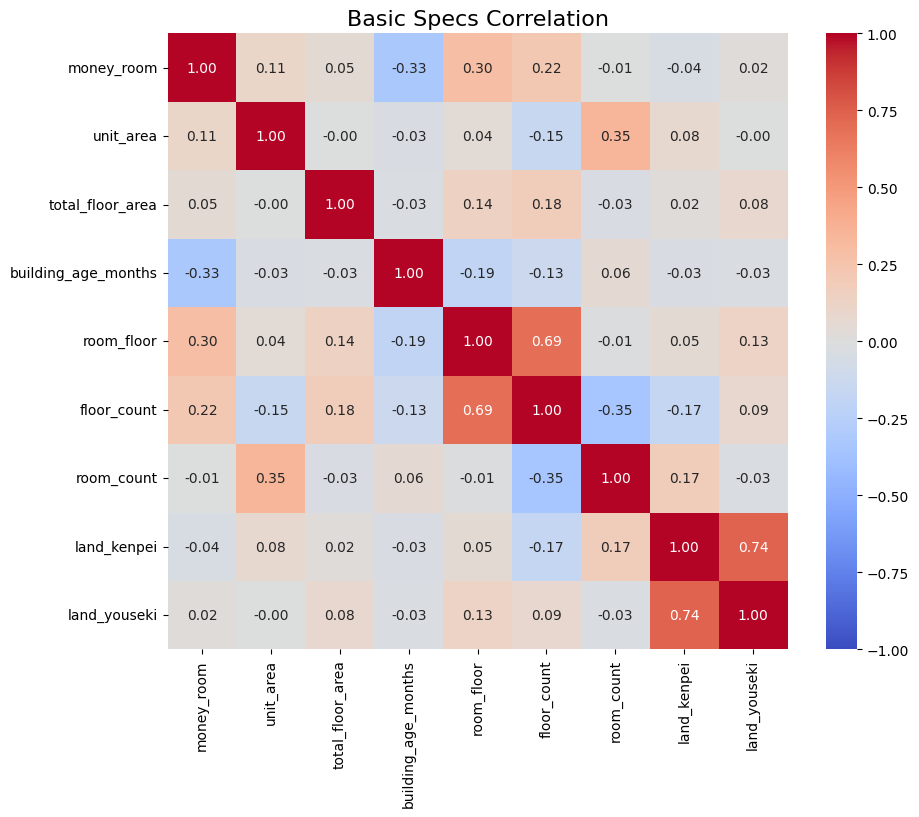

In [18]:
# 5. 実行
print("--- ① 基本スペック（広さ・築年数）との相関 ---")
plot_correlation_heatmap(cols_basic, 'Basic Specs Correlation')

--- ② 距離・利便性（GIS系）との相関 ---


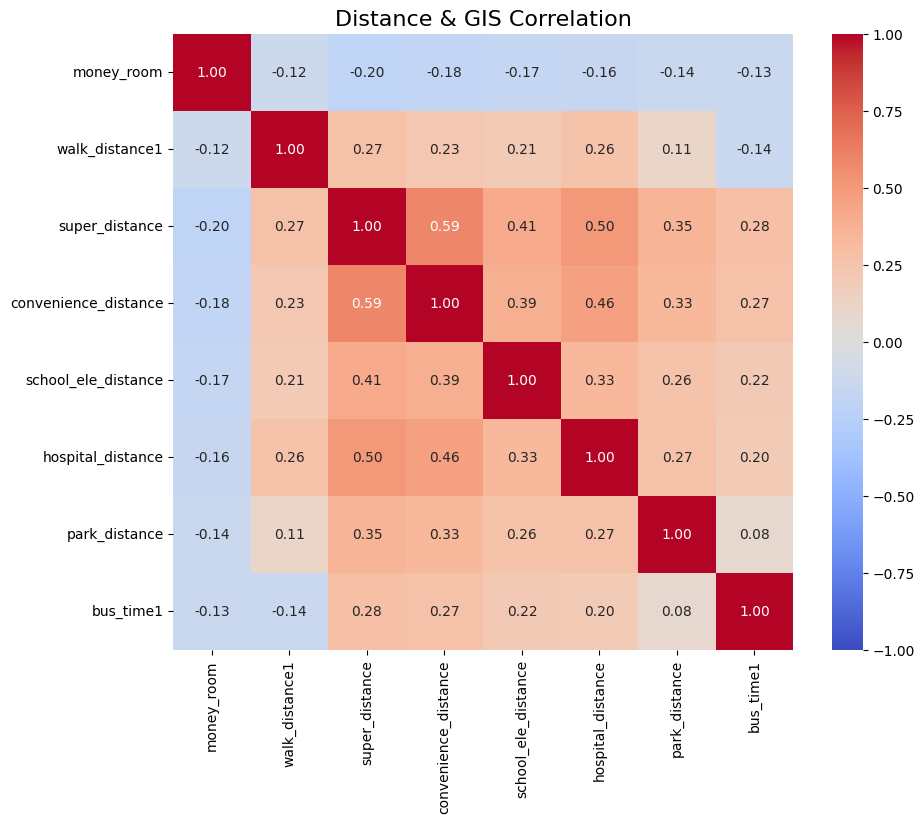

In [19]:
print("--- ② 距離・利便性（GIS系）との相関 ---")
plot_correlation_heatmap(cols_distance, 'Distance & GIS Correlation')

--- ③ お金・管理コストとの相関 ---


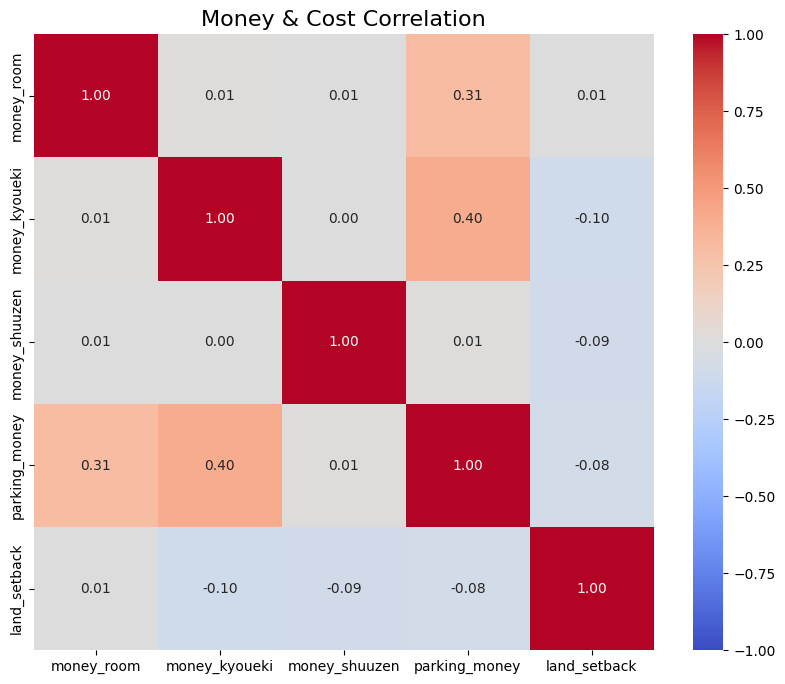

In [20]:
print("--- ③ お金・管理コストとの相関 ---")
plot_correlation_heatmap(cols_money, 'Money & Cost Correlation')

In [30]:
# 物件種別ごとの件数を確認
print(train_df['bukken_type'].value_counts())

bukken_type
1302    198614
1202    165310
Name: count, dtype: int64


In [31]:
# マンション (1302) と 戸建て (1202) にデータを分割
df_mansion = train_df[train_df['bukken_type'] == 1302]
df_house = train_df[train_df['bukken_type'] == 1202]

In [32]:
print(f"マンションデータ数: {len(df_mansion)}")
print(f"戸建てデータ数: {len(df_house)}")

# 分割した状態で、もう一度「面積」と「価格」の相関を見る
print("\n--- マンションの面積相関 ---")
print(df_mansion[['money_room', 'unit_area']].corr())

print("\n--- 戸建ての面積相関 ---")
# 戸建ては unit_area ではなく house_area (建物面積) や building_land_area (土地面積) が効くはず
print(df_house[['money_room', 'unit_area', 'house_area', 'building_land_area']].corr())

マンションデータ数: 198614
戸建てデータ数: 165310

--- マンションの面積相関 ---
            money_room  unit_area
money_room    1.000000   0.139666
unit_area     0.139666   1.000000

--- 戸建ての面積相関 ---
                    money_room  unit_area  house_area  building_land_area
money_room            1.000000   0.146792    0.034505            0.026902
unit_area             0.146792   1.000000    0.157424            0.056360
house_area            0.034505   0.157424    1.000000            0.012141
building_land_area    0.026902   0.056360    0.012141            1.000000


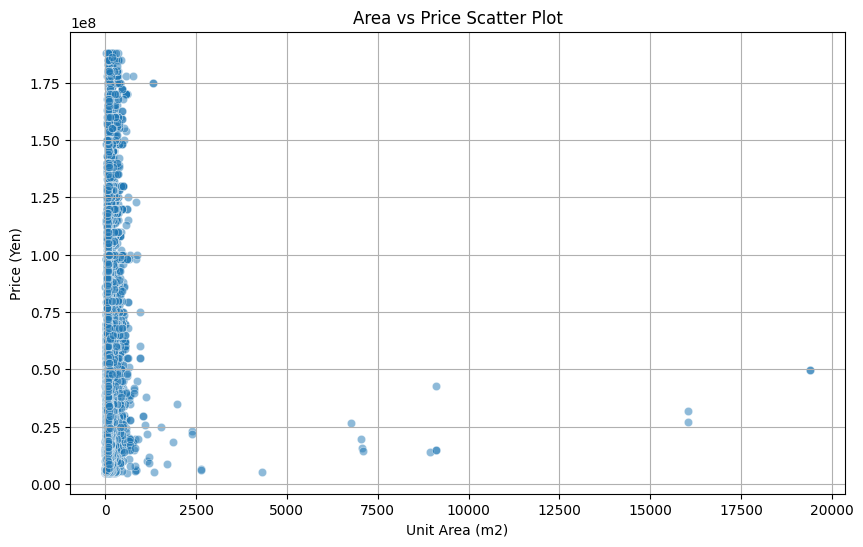

--- 面積 (unit_area) の統計 ---
count    316871.000000
mean         88.123727
std          86.670505
min           3.000000
25%          64.239998
50%          80.239998
75%         103.080002
max       19387.000000
Name: unit_area, dtype: float64

--- 価格 (money_room) の統計 ---
count    3.639240e+05
mean     2.592508e+07
std      1.857285e+07
min      4.900000e+06
25%      1.399000e+07
50%      2.180000e+07
75%      3.230000e+07
max      1.880000e+08
Name: money_room, dtype: float64

--- 面積が異常に大きい物件トップ5 ---
        money_room  unit_area  bukken_type
46729     49800000    19387.0         1202
8021      49800000    19387.0         1202
9141      31800000    16023.0         1202
48133     26800000    16023.0         1202
226796    14800000     9108.0         1202

--- 面積が異常に小さい（または0）物件トップ5 ---
        money_room  unit_area  bukken_type
20436     15800000       3.00         1202
128160    42900000       3.78         1302
76364     18800000       5.57         1202
306495    18500000       5.96    

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 散布図を描いて、異常値を目視する
plt.figure(figsize=(10, 6))
sns.scatterplot(data=train_df, x='unit_area', y='money_room', alpha=0.5)
plt.title('Area vs Price Scatter Plot')
plt.xlabel('Unit Area (m2)')
plt.ylabel('Price (Yen)')
plt.grid(True)
plt.show()

# 2. 統計量を確認する（最大値・最小値に注目！）
print("--- 面積 (unit_area) の統計 ---")
print(train_df['unit_area'].describe())

print("\n--- 価格 (money_room) の統計 ---")
print(train_df['money_room'].describe())

# 3. 怪しいデータの正体を見る
# 例えば、面積が極端に大きい（例: 500平米以上）とか、極端に小さい（10平米以下）データを表示
print("\n--- 面積が異常に大きい物件トップ5 ---")
print(train_df.sort_values('unit_area', ascending=False)[['money_room', 'unit_area', 'bukken_type']].head(5))

print("\n--- 面積が異常に小さい（または0）物件トップ5 ---")
print(train_df.sort_values('unit_area', ascending=True)[['money_room', 'unit_area', 'bukken_type']].head(5))

<ipython-input-40-3e269e523e7f>:7: DtypeWarning: Columns (63) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/work/Real_estate/train/train.csv')
/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)


グラフを生成中...
--- マンションの相関図 ---


/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


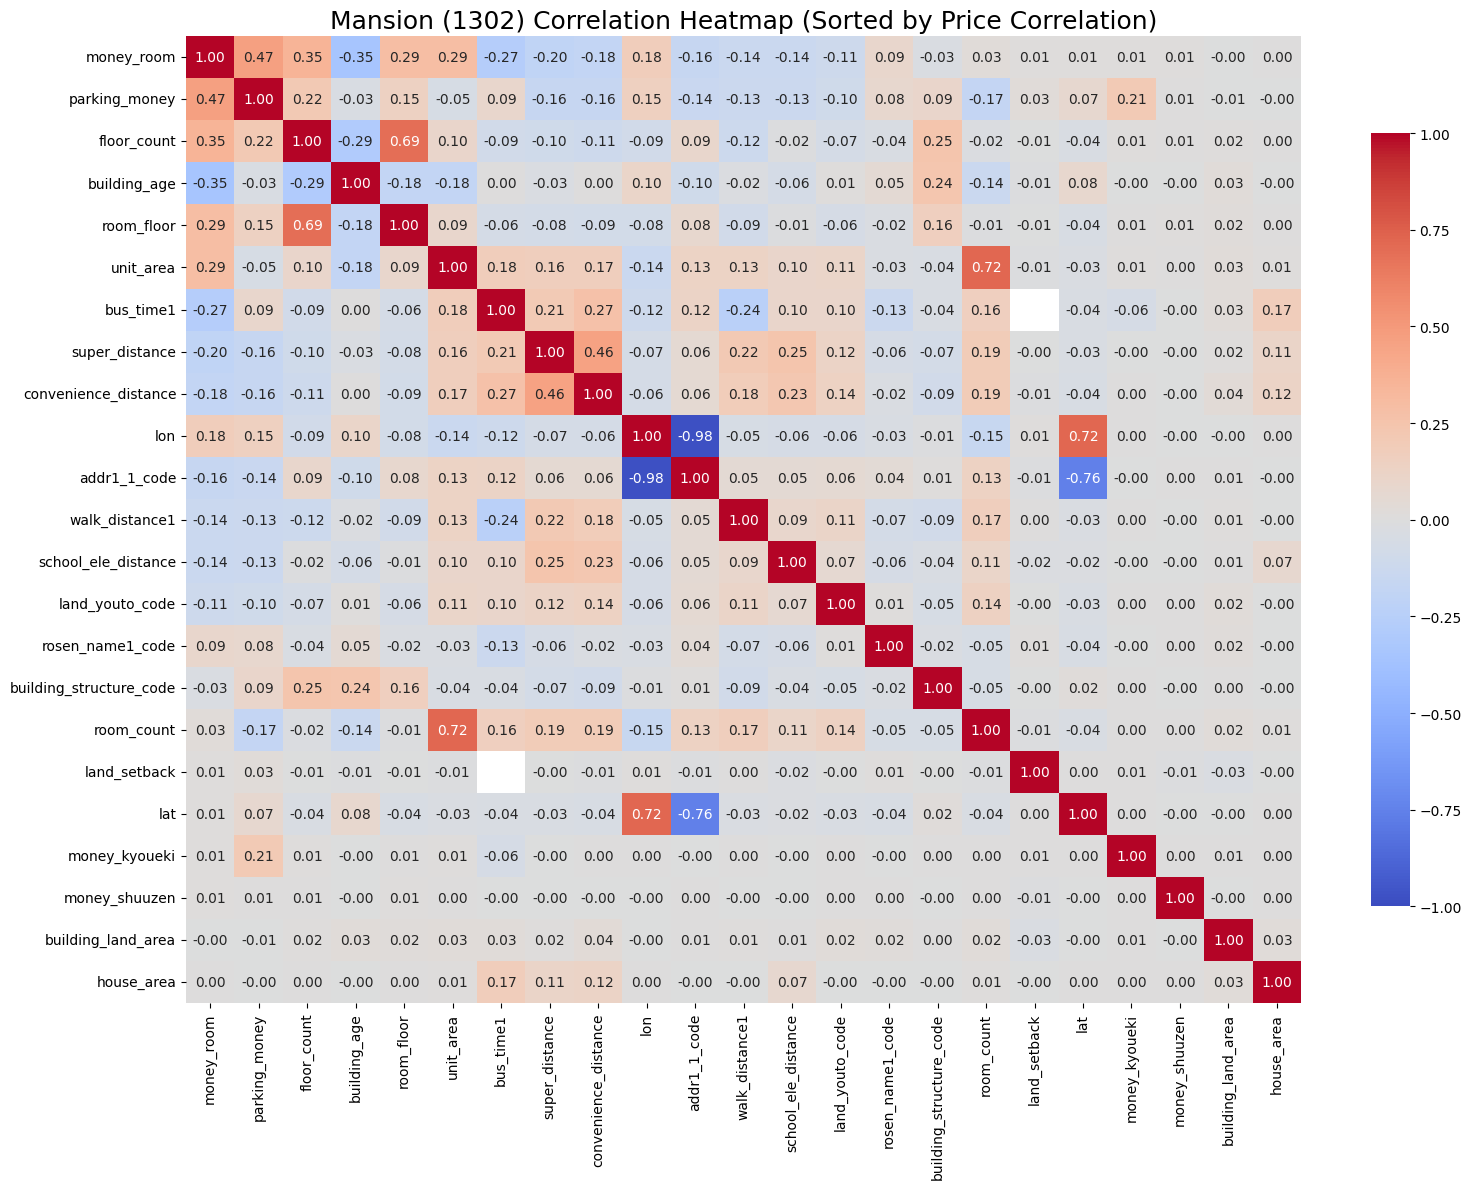

--- 戸建ての相関図 ---


/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


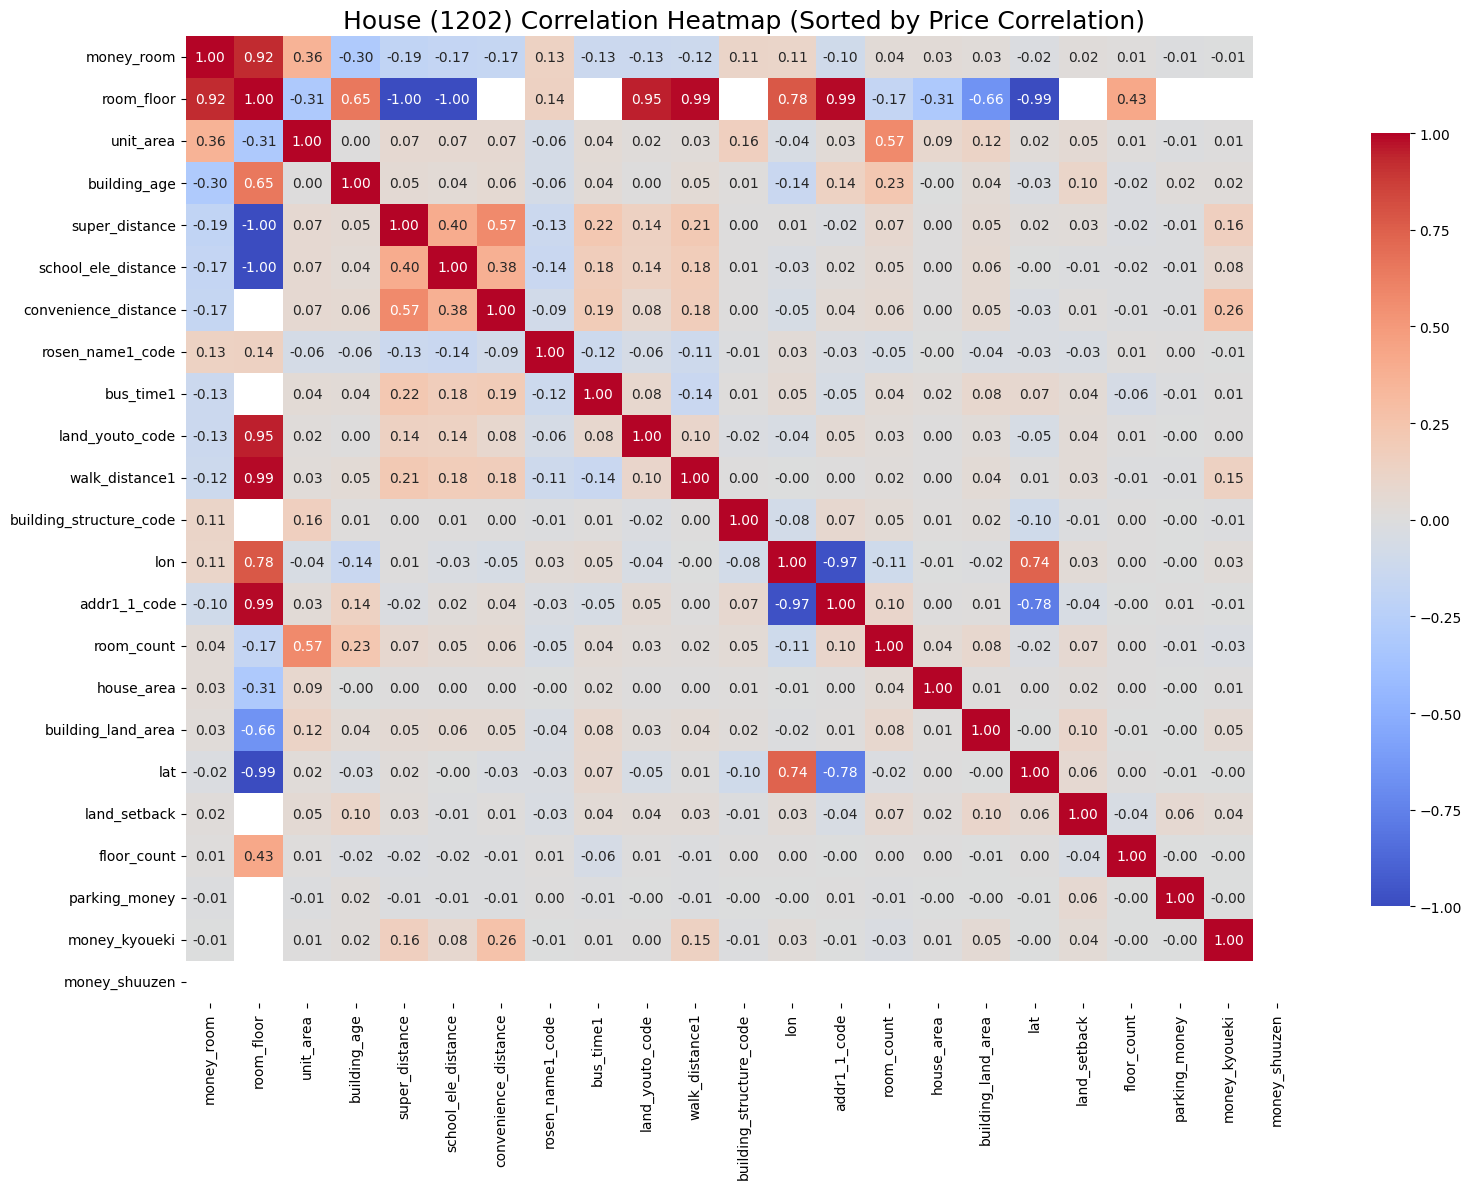

In [40]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. データ読み込みとクリーニング（外れ値除去）
df = pd.read_csv('/work/Real_estate/train/train.csv')
df_clean = df[(df['unit_area'] > 10) & (df['unit_area'] < 500)].copy()

# 2. 築年数計算
def calculate_age(row):
    try:
        if pd.isna(row['year_built']) or pd.isna(row['target_ym']):
            return np.nan
        diff = int(row['target_ym']) - int(row['year_built'])
        return (diff // 100) * 12 + (diff % 100)
    except:
        return np.nan

df_clean['building_age'] = df_clean.apply(calculate_age, axis=1)

# 3. カテゴリ変数の数値化（相関用）
cols_cat = ['land_youto', 'building_structure', 'addr1_1', 'rosen_name1']
for c in cols_cat:
    df_clean[f'{c}_code'] = df_clean[c].astype('category').cat.codes

# 4. 精鋭変数リストの定義（ターゲット変数を含む）
target = 'money_room'
cols_numeric = [
    'unit_area', 'building_age',             # 基本
    'walk_distance1', 'bus_time1',          # 交通
    'room_floor', 'floor_count', 'room_count', # 階数・部屋
    'money_kyoueki', 'money_shuuzen', 'parking_money', # お金
    'house_area', 'building_land_area', 'land_setback', # 戸建て・土地
    'super_distance', 'convenience_distance', 'school_ele_distance', # 施設
    'lon', 'lat' # 座標
]
cols_encoded = [f'{c}_code' for c in cols_cat]
check_list = [target] + cols_numeric + cols_encoded

# 5. ヒートマップ作成関数
def plot_target_heatmap(df_subset, title):
    # 存在するカラムのみ抽出
    valid_cols = [c for c in check_list if c in df_subset.columns]
    
    # 相関行列の計算
    corr_matrix = df_subset[valid_cols].corr()
    
    # money_room（価格）との相関が強い順に並び替え（見やすくするため）
    # abs()で絶対値ソート
    sorted_index = corr_matrix[[target]].sort_values(by=target, key=abs, ascending=False).index
    corr_matrix_sorted = corr_matrix.loc[sorted_index, sorted_index]
    
    # 描画 (サイズを大きく設定: 16x12インチ)
    plt.figure(figsize=(16, 12))
    sns.heatmap(corr_matrix_sorted, annot=True, fmt=".2f", 
                cmap='coolwarm', vmin=-1, vmax=1, center=0,
                cbar_kws={'shrink': .8})
    plt.title(f'{title} Correlation Heatmap (Sorted by Price Correlation)', fontsize=18)
    plt.tight_layout()
    plt.show()

# --- 実行 ---
print("グラフを生成中...")

# ① マンション (1302)
print("--- マンションの相関図 ---")
plot_target_heatmap(df_clean[df_clean['bukken_type'] == 1302], "Mansion (1302)")

# ② 戸建て (1202)
print("--- 戸建ての相関図 ---")
plot_target_heatmap(df_clean[df_clean['bukken_type'] == 1202], "House (1202)")

<ipython-input-41-19fb9eac1933>:7: DtypeWarning: Columns (63) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/work/Real_estate/train/train.csv')
/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)



========== マンション (Mansion) ==========
▼ マンション (Mansion): 価格との相関ランキング
                      money_room
money_room                1.0000
parking_money             0.4665
floor_count               0.3532
building_age             -0.3461
room_floor                0.2932
unit_area                 0.2911
bus_time1                -0.2667
super_distance           -0.1973
convenience_distance     -0.1833
lon                       0.1757
walk_distance1           -0.1388
school_ele_distance      -0.1381
room_count                0.0283
land_setback              0.0127
lat                       0.0124
money_kyoueki             0.0117
money_shuuzen             0.0083
building_land_area       -0.0044
house_area                0.0028


/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
<ipython-input-41-19fb9eac1933>:59: UserWarning: Glyph 12510 (\N{KATAKANA LETTER MA}) missing from current font.
  plt.tight_layout()
<ipython-input-41-19fb9eac1933>:59: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from current font.
  plt.tight_layout()
<ipython-input-41-19fb9eac1933>:59: UserWarning: Glyph 12471 (\N{KATAKANA LETTER SI}) missing from current font.
  plt.tight_layout()
<ipython-input-41-19fb9eac1933>:59: UserWarning: Glyph 12519 (\N{KATAKANA LETTER SMALL YO}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12510 (\N{KATAKANA LETTER MA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from 

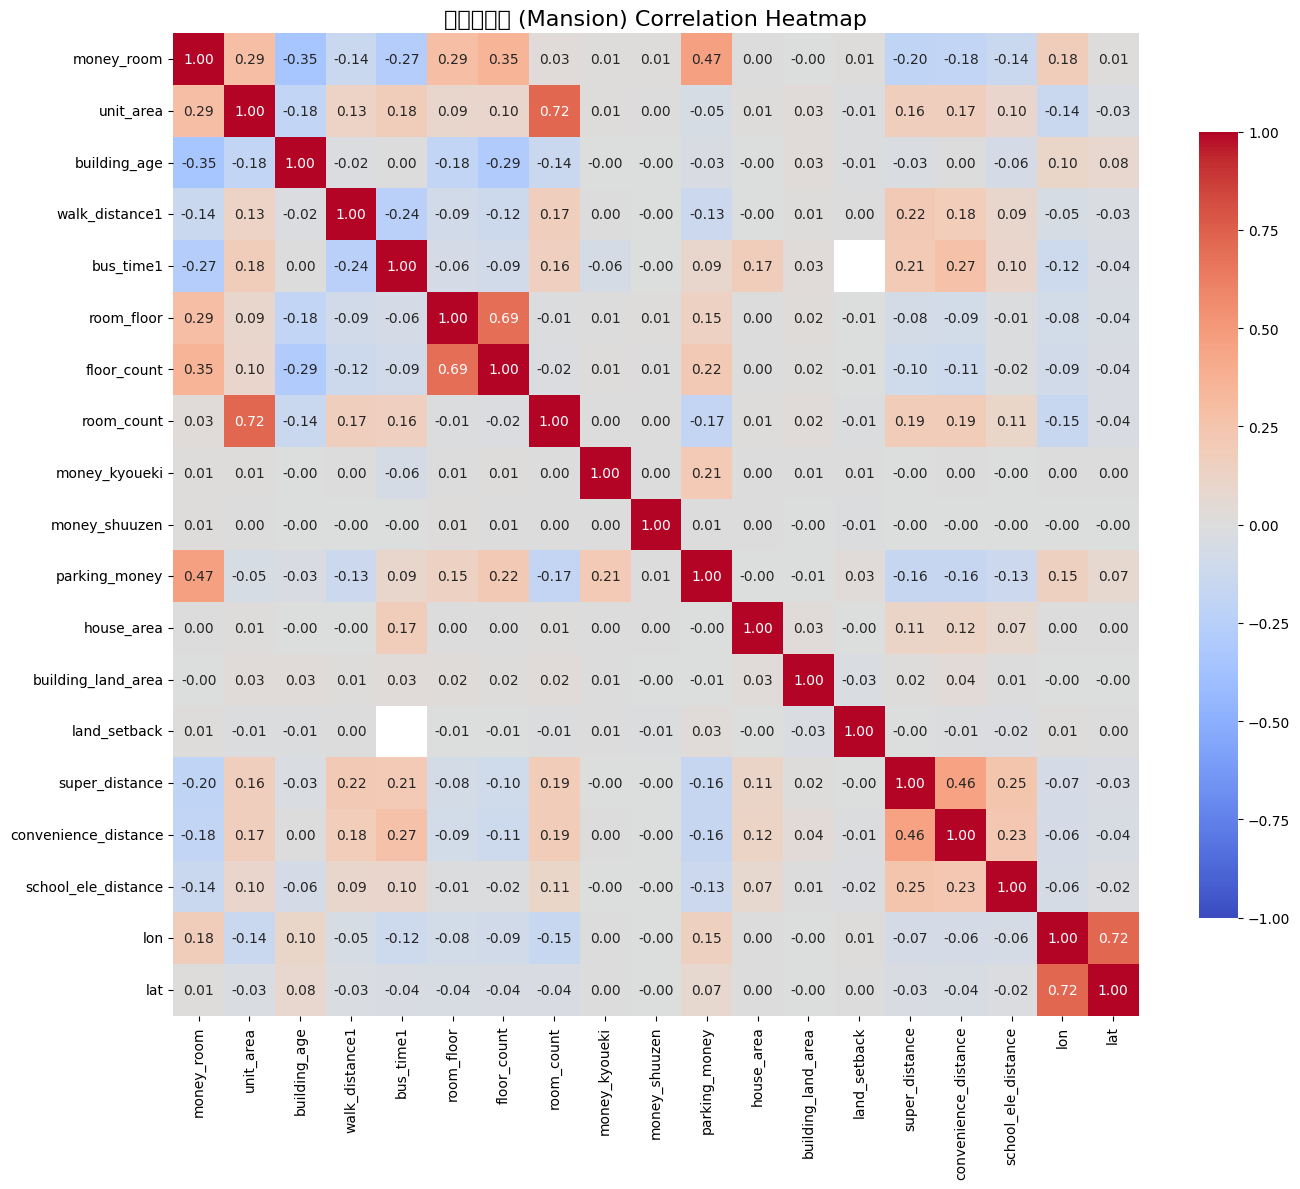


========== 戸建て (House) ==========
▼ 戸建て (House): 価格との相関ランキング
                      money_room
money_room                1.0000
room_floor                0.9230
unit_area                 0.3601
building_age             -0.2973
super_distance           -0.1920
school_ele_distance      -0.1733
convenience_distance     -0.1661
bus_time1                -0.1312
walk_distance1           -0.1241
lon                       0.1089
room_count                0.0372
house_area                0.0318
building_land_area        0.0254
lat                      -0.0195
land_setback              0.0182
floor_count               0.0149
parking_money            -0.0082
money_kyoueki            -0.0067
money_shuuzen                NaN


/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
<ipython-input-41-19fb9eac1933>:59: UserWarning: Glyph 25144 (\N{CJK UNIFIED IDEOGRAPH-6238}) missing from current font.
  plt.tight_layout()
<ipython-input-41-19fb9eac1933>:59: UserWarning: Glyph 24314 (\N{CJK UNIFIED IDEOGRAPH-5EFA}) missing from current font.
  plt.tight_layout()
<ipython-input-41-19fb9eac1933>:59: UserWarning: Glyph 12390 (\N{HIRAGANA LETTER TE}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25144 (\N{CJK UNIFIED IDEOGRAPH-6238}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 24314 (\N{CJK UNIFIED IDEOGRAPH-5EFA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/co

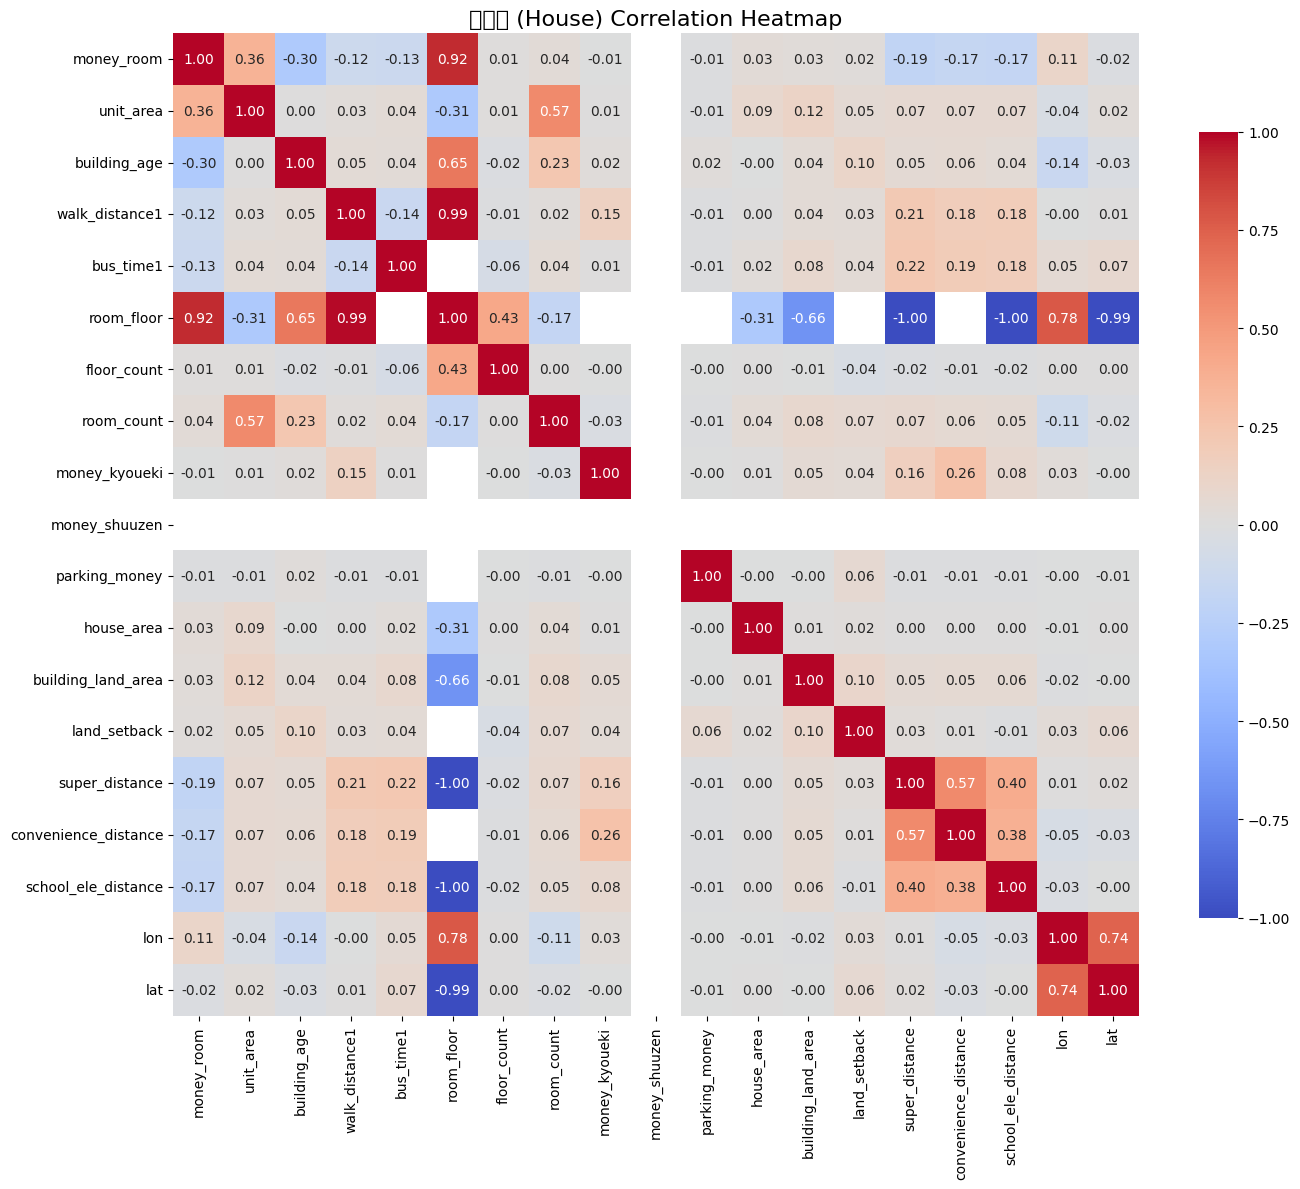

In [41]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. データ読み込み & 外れ値除去 (必須の前処理)
df = pd.read_csv('/work/Real_estate/train/train.csv')
# 面積の外れ値除去（これを行わないと相関が出ません）
df_clean = df[(df['unit_area'] > 10) & (df['unit_area'] < 500)].copy()

# 2. 築年数計算 (YYYYMM -> 築月数)
def calculate_age(row):
    try:
        if pd.isna(row['year_built']) or pd.isna(row['target_ym']):
            return np.nan
        diff = int(row['target_ym']) - int(row['year_built'])
        return (diff // 100) * 12 + (diff % 100)
    except:
        return np.nan

df_clean['building_age'] = df_clean.apply(calculate_age, axis=1)

# 3. ご指定の全カラムリスト
target = 'money_room'
cols_numeric = [
    'unit_area', 'building_age',             # 基本
    'walk_distance1', 'bus_time1',          # 交通
    'room_floor', 'floor_count', 'room_count', # 階数・部屋
    'money_kyoueki', 'money_shuuzen', 'parking_money', # お金
    'house_area', 'building_land_area', 'land_setback', # 戸建て・土地
    'super_distance', 'convenience_distance', 'school_ele_distance', # 施設
    'lon', 'lat' # 座標
]

# 相関行列に含める全カラム
check_cols = [target] + cols_numeric

# 4. ヒートマップ作成関数
def plot_full_heatmap(df_subset, title):
    print(f"\n{'='*10} {title} {'='*10}")
    
    # 存在するカラムのみ抽出
    valid_cols = [c for c in check_cols if c in df_subset.columns]
    
    # 相関行列の計算 (数値型のみ)
    # ※自動的に欠損値を除外してペアごとに計算されます
    corr_matrix = df_subset[valid_cols].corr()
    
    # ターゲット(価格)との相関ランキング表示
    print(f"▼ {title}: 価格との相関ランキング")
    target_corr = corr_matrix[[target]].sort_values(by=target, key=abs, ascending=False)
    print(target_corr)
    
    # ヒートマップ描画
    plt.figure(figsize=(14, 12)) # サイズ大きめ
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', 
                vmin=-1, vmax=1, center=0, cbar_kws={'shrink': .8})
    plt.title(f'{title} Correlation Heatmap', fontsize=16)
    plt.tight_layout()
    plt.show()

# --- 実行 ---

# ① マンション (1302)
plot_full_heatmap(df_clean[df_clean['bukken_type'] == 1302], "マンション (Mansion)")

# ② 戸建て (1202)
plot_full_heatmap(df_clean[df_clean['bukken_type'] == 1202], "戸建て (House)")

<ipython-input-42-a718b591b5f5>:13: DtypeWarning: Columns (63) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/work/Real_estate/train/train.csv')
/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)



========== Mansion Model Training ==========
Training until validation scores don't improve for 100 rounds
[200]	valid_0's rmse: 0.242215
[400]	valid_0's rmse: 0.230282
[600]	valid_0's rmse: 0.22466
[800]	valid_0's rmse: 0.220847
[1000]	valid_0's rmse: 0.218167
[1200]	valid_0's rmse: 0.215994
[1400]	valid_0's rmse: 0.213963
[1600]	valid_0's rmse: 0.212372
[1800]	valid_0's rmse: 0.21096
[2000]	valid_0's rmse: 0.209874
[2200]	valid_0's rmse: 0.208656
[2400]	valid_0's rmse: 0.207597
[2600]	valid_0's rmse: 0.206793
[2800]	valid_0's rmse: 0.206018
[3000]	valid_0's rmse: 0.205373
[3200]	valid_0's rmse: 0.204806
[3400]	valid_0's rmse: 0.204251
[3600]	valid_0's rmse: 0.203705
[3800]	valid_0's rmse: 0.203183
[4000]	valid_0's rmse: 0.202721
[4200]	valid_0's rmse: 0.202151
[4400]	valid_0's rmse: 0.201696
[4600]	valid_0's rmse: 0.201323
[4800]	valid_0's rmse: 0.20093
[5000]	valid_0's rmse: 0.200561
Did not meet early stopping. Best iteration is:
[4999]	valid_0's rmse: 0.20056

🏆 Mansion Model Fin

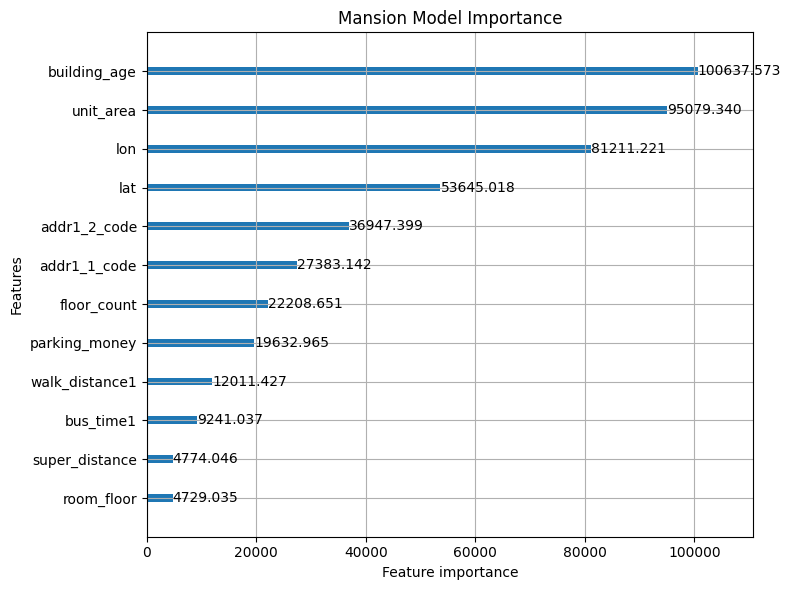


========== House Model Training ==========
Training until validation scores don't improve for 100 rounds
[200]	valid_0's rmse: 0.349572
[400]	valid_0's rmse: 0.337214
[600]	valid_0's rmse: 0.330642
[800]	valid_0's rmse: 0.326162
[1000]	valid_0's rmse: 0.322296
[1200]	valid_0's rmse: 0.319181
[1400]	valid_0's rmse: 0.316634
[1600]	valid_0's rmse: 0.314406
[1800]	valid_0's rmse: 0.312183
[2000]	valid_0's rmse: 0.310217
[2200]	valid_0's rmse: 0.308549
[2400]	valid_0's rmse: 0.307065
[2600]	valid_0's rmse: 0.305687
[2800]	valid_0's rmse: 0.304348
[3000]	valid_0's rmse: 0.303195
[3200]	valid_0's rmse: 0.302014
[3400]	valid_0's rmse: 0.300834
[3600]	valid_0's rmse: 0.299837
[3800]	valid_0's rmse: 0.29893
[4000]	valid_0's rmse: 0.298056
[4200]	valid_0's rmse: 0.297162
[4400]	valid_0's rmse: 0.296328
[4600]	valid_0's rmse: 0.295629
[4800]	valid_0's rmse: 0.294833
[5000]	valid_0's rmse: 0.294183
Did not meet early stopping. Best iteration is:
[4999]	valid_0's rmse: 0.29418

🏆 House Model Final

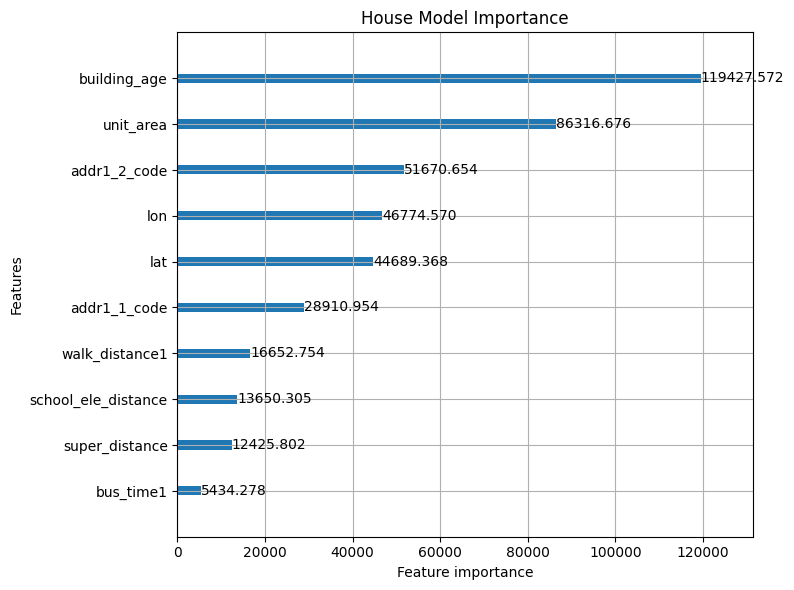


✨ Overall Estimated Score: 0.1936


In [42]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import LabelEncoder

# ---------------------------------------------------------
# 1. データ準備 & 前処理
# ---------------------------------------------------------
df = pd.read_csv('/work/Real_estate/train/train.csv')

# 外れ値除去 (面積 10~500m2)
df = df[(df['unit_area'] > 10) & (df['unit_area'] < 500)].copy()

# 築年数計算 (月単位)
def calculate_age_months(row):
    try:
        if pd.isna(row['year_built']) or pd.isna(row['target_ym']):
            return np.nan
        diff = int(row['target_ym']) - int(row['year_built'])
        return (diff // 100) * 12 + (diff % 100)
    except:
        return np.nan

df['building_age'] = df.apply(calculate_age_months, axis=1)

# カテゴリ変数のエンコード (都道府県など)
cols_cat = ['addr1_1', 'addr1_2']
for c in cols_cat:
    le = LabelEncoder()
    df[f'{c}_code'] = le.fit_transform(df[c].astype(str))

# ---------------------------------------------------------
# 2. モデル投入変数の定義 (精鋭リスト)
# ---------------------------------------------------------
target = 'money_room'

# マンション用: 駐車場代(parking_money)がキー
features_mansion = [
    'unit_area', 'building_age', 
    'walk_distance1', 'bus_time1',
    'parking_money',              # 重要: 立地プロキシ
    'floor_count', 'room_floor',  # 重要: 階数
    'super_distance',             # 重要: GIS
    'lon', 'lat',                 # 重要: 座標
    'addr1_1_code', 'addr1_2_code' # 地域コード
]

# 戸建て用: room_floorは危険なので除外
features_house = [
    'unit_area', 'building_age',
    'walk_distance1', 'bus_time1',
    'super_distance', 'school_ele_distance', # 戸建ては学校距離も効く
    'lon', 'lat',
    'addr1_1_code', 'addr1_2_code'
]

# ---------------------------------------------------------
# 3. 学習と評価の実行関数
# ---------------------------------------------------------
def train_base_model(df_full, features, model_name):
    print(f"\n{'='*10} {model_name} Training {'='*10}")
    
    # 必要なデータのみ抽出 & 欠損対応
    # LightGBMは欠損を扱えますが、infなどが混じるとエラーになるため確認
    data = df_full[features + [target]].copy()
    
    # 目的変数と特徴量を分ける
    X = data[features]
    y = data[target]
    
    # 【MAPE対策】目的変数を対数変換 log(y)
    y_log = np.log1p(y)
    
    # データ分割 (Train: 80%, Valid: 20%)
    X_train, X_valid, y_train_log, y_valid_log = train_test_split(
        X, y_log, test_size=0.2, random_state=42
    )
    
    # LightGBM Dataset
    train_data = lgb.Dataset(X_train, label=y_train_log)
    valid_data = lgb.Dataset(X_valid, label=y_valid_log, reference=train_data)
    
    # パラメータ (ベースライン用)
    params = {
        'objective': 'regression',
        'metric': 'rmse',       # 学習はRMSEで行う
        'boosting_type': 'gbdt',
        'learning_rate': 0.05,
        'num_leaves': 31,
        'verbosity': -1,
        'seed': 42
    }
    
    # 学習
    model = lgb.train(
        params,
        train_data,
        valid_sets=[valid_data],
        num_boost_round=5000,
        callbacks=[
            lgb.early_stopping(stopping_rounds=100),
            lgb.log_evaluation(period=200)
        ]
    )
    
    # 予測 & 評価
    preds_log = model.predict(X_valid)
    preds = np.expm1(preds_log) # 対数を元に戻す
    y_valid = np.expm1(y_valid_log)
    
    # MAPE算出
    score = mean_absolute_percentage_error(y_valid, preds)
    print(f"\n🏆 {model_name} Final MAPE Score: {score:.4f} ({score*100:.2f}%)")
    
    # 特徴量重要度プロット
    lgb.plot_importance(model, importance_type='gain', figsize=(8, 6), title=f'{model_name} Importance')
    plt.tight_layout()
    plt.show()
    
    return score

# --- 実行 ---

# ① マンションモデル
score_mansion = train_base_model(
    df[df['bukken_type'] == 1302], 
    features_mansion, 
    "Mansion Model"
)

# ② 戸建てモデル
score_house = train_base_model(
    df[df['bukken_type'] == 1202], 
    features_house, 
    "House Model"
)

# 総合スコア (データ数で加重平均しても良いが、単純平均で目安を見る)
print(f"\n✨ Overall Estimated Score: {(score_mansion + score_house) / 2:.4f}")

<ipython-input-43-67eddc091859>:13: DtypeWarning: Columns (63) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/work/Real_estate/train/train.csv')
/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)


--- モデル再構築中 ---
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's rmse: 0.218167
✅ Mansion Model MAPE Score: 0.1728
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[999]	valid_0's rmse: 0.322291
✅ House Model MAPE Score: 0.2576

--- 誤差分析グラフの生成 ---


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


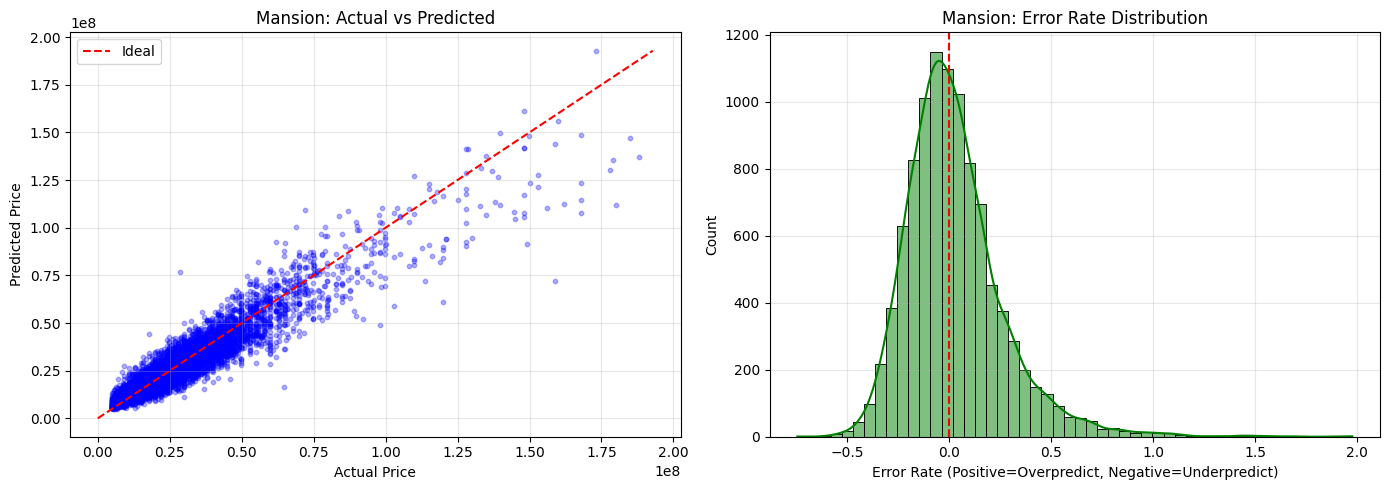

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


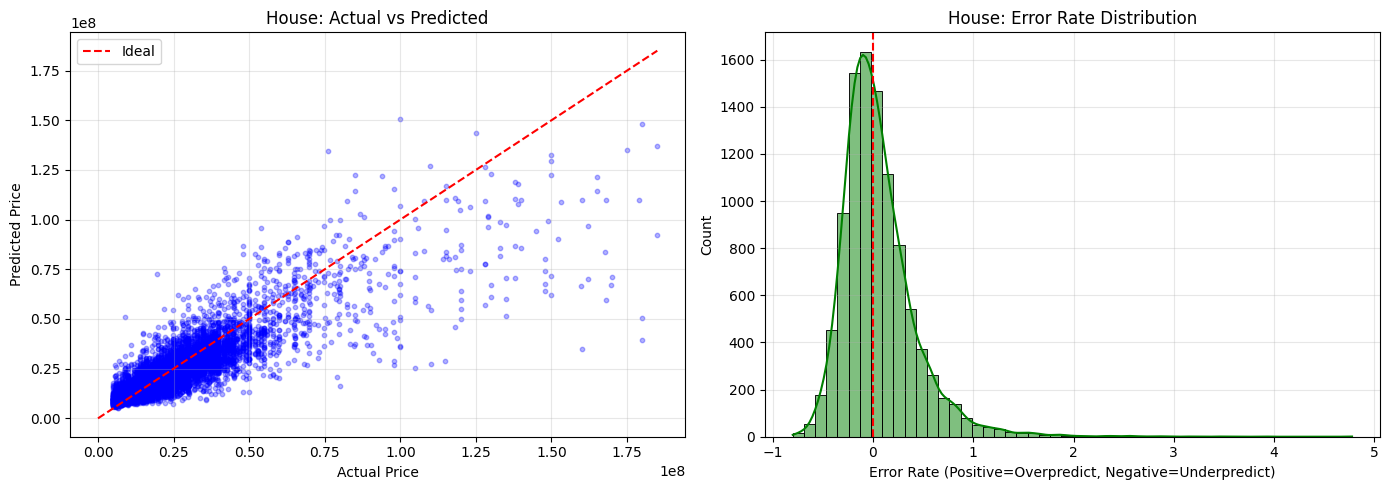

In [43]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import LabelEncoder

# ---------------------------------------------------------
# 1. データ準備（先ほどと同じ）
# ---------------------------------------------------------
df = pd.read_csv('/work/Real_estate/train/train.csv')
df = df[(df['unit_area'] > 10) & (df['unit_area'] < 500)].copy()

def calculate_age_months(row):
    try:
        if pd.isna(row['year_built']) or pd.isna(row['target_ym']):
            return np.nan
        diff = int(row['target_ym']) - int(row['year_built'])
        return (diff // 100) * 12 + (diff % 100)
    except:
        return np.nan

df['building_age'] = df.apply(calculate_age_months, axis=1)

cols_cat = ['addr1_1', 'addr1_2']
for c in cols_cat:
    le = LabelEncoder()
    df[f'{c}_code'] = le.fit_transform(df[c].astype(str))

target = 'money_room'

# 特徴量リスト
features_mansion = [
    'unit_area', 'building_age', 'walk_distance1', 'bus_time1',
    'parking_money', 'floor_count', 'room_floor',
    'super_distance', 'lon', 'lat', 'addr1_1_code', 'addr1_2_code'
]

features_house = [
    'unit_area', 'building_age', 'walk_distance1', 'bus_time1',
    'super_distance', 'school_ele_distance', 'lon', 'lat',
    'addr1_1_code', 'addr1_2_code'
]

# ---------------------------------------------------------
# 2. 学習関数（ここを修正：モデルも返すように変更）
# ---------------------------------------------------------
def train_base_model(df_full, features, model_name):
    # データ抽出
    data = df_full[features + [target]].copy()
    X = data[features]
    y = data[target]
    y_log = np.log1p(y) # 対数変換
    
    # 分割
    X_train, X_valid, y_train_log, y_valid_log = train_test_split(
        X, y_log, test_size=0.2, random_state=42
    )
    
    train_data = lgb.Dataset(X_train, label=y_train_log)
    valid_data = lgb.Dataset(X_valid, label=y_valid_log, reference=train_data)
    
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'boosting_type': 'gbdt',
        'learning_rate': 0.05,
        'num_leaves': 31,
        'verbosity': -1,
        'seed': 42
    }
    
    # 学習
    model = lgb.train(
        params,
        train_data,
        valid_sets=[valid_data],
        num_boost_round=1000, # 速く終わらせるため少し減らしてもOK
        callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(0)]
    )
    
    # 評価
    preds_log = model.predict(X_valid)
    preds = np.expm1(preds_log)
    y_valid = np.expm1(y_valid_log)
    score = mean_absolute_percentage_error(y_valid, preds)
    
    print(f"✅ {model_name} MAPE Score: {score:.4f}")
    
    # 【修正点】モデルとスコアの両方を返す
    return model, score

# ---------------------------------------------------------
# 3. 再学習の実行（ここで変数にモデルを格納）
# ---------------------------------------------------------
print("--- モデル再構築中 ---")

model_mansion, score_m = train_base_model(
    df[df['bukken_type'] == 1302], 
    features_mansion, 
    "Mansion Model"
)

model_house, score_h = train_base_model(
    df[df['bukken_type'] == 1202], 
    features_house, 
    "House Model"
)

# ---------------------------------------------------------
# 4. 誤差分析のプロット（モデル変数がある状態で実行）
# ---------------------------------------------------------
def plot_prediction_error(model, df_subset, features, title):
    # データ準備（Validデータだけでなく全体または一部で可視化）
    # ここでは処理時間を考慮してサンプリング（全件だと重い場合があるため）
    if len(df_subset) > 10000:
        df_viz = df_subset.sample(10000, random_state=42)
    else:
        df_viz = df_subset
        
    X = df_viz[features]
    y = df_viz[target]
    
    # 予測
    preds_log = model.predict(X)
    preds = np.expm1(preds_log)
    
    # データフレーム化
    res_df = pd.DataFrame({
        'Actual': y,
        'Predicted': preds,
        'Error_Rate': (preds - y) / y
    })
    
    # プロット
    plt.figure(figsize=(14, 5))
    
    # ① 散布図
    plt.subplot(1, 2, 1)
    plt.scatter(res_df['Actual'], res_df['Predicted'], alpha=0.3, s=10, color='blue')
    # 理想線 (y=x)
    max_val = max(res_df['Actual'].max(), res_df['Predicted'].max())
    plt.plot([0, max_val], [0, max_val], 'r--', label='Ideal')
    plt.xlabel('Actual Price')
    plt.ylabel('Predicted Price')
    plt.title(f'{title}: Actual vs Predicted')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # ② 誤差率のヒストグラム
    plt.subplot(1, 2, 2)
    sns.histplot(res_df['Error_Rate'], bins=50, kde=True, color='green')
    plt.axvline(0, color='red', linestyle='--')
    plt.xlabel('Error Rate (Positive=Overpredict, Negative=Underpredict)')
    plt.title(f'{title}: Error Rate Distribution')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("\n--- 誤差分析グラフの生成 ---")
plot_prediction_error(model_mansion, df[df['bukken_type'] == 1302], features_mansion, "Mansion")
plot_prediction_error(model_house, df[df['bukken_type'] == 1202], features_house, "House")

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder

# ---------------------------------------------------------
# 1. データの読み込み
# ---------------------------------------------------------
# ファイル名は適宜変更してください
train = pd.read_csv('/work/Real_estate/train/train.csv')
test = pd.read_csv('/work/Real_estate/test/test.csv')
sample_sub = pd.read_csv('/work/Real_estate/sample_submit.csv')

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")

# ---------------------------------------------------------
# 2. 前処理 & 特徴量エンジニアリング（学習・テスト共通）
# ---------------------------------------------------------

# ① 学習データのみ外れ値除去（テストデータは消してはいけない）
train = train[(train['unit_area'] > 10) & (train['unit_area'] < 500)].copy()

# ② データを結合して一括処理（エンコーディングの整合性のため）
train['is_train'] = 1
test['is_train'] = 0
# money_roomはテストデータにないので一旦NaNにしておくか、無視される
all_data = pd.concat([train, test], sort=False).reset_index(drop=True)

# ③ 築年数計算 (月単位)
def calculate_age_months(row):
    try:
        # テストデータにも target_ym がある前提
        if pd.isna(row['year_built']) or pd.isna(row['target_ym']):
            return np.nan
        t_y, t_m = divmod(int(row['target_ym']), 100)
        b_y, b_m = divmod(int(row['year_built']), 100)
        return (t_y - b_y) * 12 + (t_m - b_m)
    except:
        return np.nan

all_data['building_age'] = all_data.apply(calculate_age_months, axis=1)

# ④ カテゴリ変数のエンコーディング
cols_cat = ['addr1_1', 'addr1_2', 'land_youto', 'building_structure']
for c in cols_cat:
    le = LabelEncoder()
    # 欠損は'missing'として文字化してからエンコード
    all_data[f'{c}_code'] = le.fit_transform(all_data[c].fillna('missing').astype(str))

# ---------------------------------------------------------
# 3. データの再分割
# ---------------------------------------------------------
train_final = all_data[all_data['is_train'] == 1].copy()
test_final = all_data[all_data['is_train'] == 0].copy()

# ---------------------------------------------------------
# 4. モデル学習と予測の実行
# ---------------------------------------------------------
target = 'money_room'

# 特徴量リスト（先ほど確定したもの）
features_mansion = [
    'unit_area', 'building_age', 'walk_distance1', 'bus_time1',
    'parking_money', 'floor_count', 'room_floor',
    'super_distance', 'lon', 'lat', 'addr1_1_code', 'addr1_2_code'
]

features_house = [
    'unit_area', 'building_age', 'walk_distance1', 'bus_time1',
    'super_distance', 'school_ele_distance', 'lon', 'lat',
    'addr1_1_code', 'addr1_2_code'
]

def train_predict(train_df, test_df, features):
    # 学習データ作成
    X_train = train_df[features]
    y_train = np.log1p(train_df[target]) # 対数変換
    
    # 全データで学習（Validなしで本番学習）
    train_set = lgb.Dataset(X_train, label=y_train)
    
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'boosting_type': 'gbdt',
        'learning_rate': 0.05,
        'num_leaves': 31,
        'verbosity': -1,
        'seed': 42
    }
    
    # 学習実行
    model = lgb.train(
        params,
        train_set,
        num_boost_round=1200 # Validがないので少し多めに回すか、CVで決めた回数を指定
    )
    
    # 予測実行
    if len(test_df) > 0:
        preds_log = model.predict(test_df[features])
        preds = np.expm1(preds_log) # 元に戻す
        return preds
    else:
        return []

# --- マンション予測 ---
print("Predicting Mansion...")
test_mansion_idx = test_final['bukken_type'] == 1302
preds_mansion = train_predict(
    train_final[train_final['bukken_type'] == 1302],
    test_final[test_mansion_idx],
    features_mansion
)
# 結果を格納（インデックスを合わせる）
test_final.loc[test_mansion_idx, 'prediction'] = preds_mansion

# --- 戸建て予測 ---
print("Predicting House...")
test_house_idx = test_final['bukken_type'] == 1202
preds_house = train_predict(
    train_final[train_final['bukken_type'] == 1202],
    test_final[test_house_idx],
    features_house
)
# 結果を格納
test_final.loc[test_house_idx, 'prediction'] = preds_house


<ipython-input-46-cedaf3977842>:10: DtypeWarning: Columns (63) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv('/work/Real_estate/train/train.csv')
<ipython-input-46-cedaf3977842>:11: DtypeWarning: Columns (46,55,56,63,146) have mixed types. Specify dtype option on import or set low_memory=False.
  test = pd.read_csv('/work/Real_estate/test/test.csv')


Train shape: (363924, 149)
Test shape: (112437, 149)


/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)


Predicting Mansion...
Predicting House...
Submission ID column: 000000
Submission Target column: 97228990
⚠ Warning: '000000' not found in test data. Using first column of test data as ID.
⚠ Warning: 112436 predictions are missing in submission file!
✅ File 'submission.csv' created successfully!


In [51]:
# ---------------------------------------------------------
# 5. 提出ファイルの作成 (シンプル版)
# ---------------------------------------------------------

# ① ヘッダーなしで読み込む (1行目を列名にしないため)
sub_df = pd.read_csv('/work/Real_estate/sample_submit.csv', header=None)

# ② 2列目 (index=1) に予測値をそのまま上書き
# .values を使うことで、インデックスのズレを無視して値を流し込みます
sub_df.iloc[:, 1] = test_final['prediction'].values

# ③ ヘッダーなし、インデックスなしで保存
sub_df.to_csv('submission.csv', index=False, header=False)

print("✅ File 'submission.csv' created successfully!")
print(f"Shape: {sub_df.shape}")
print("先頭5行の確認:")
print(sub_df.head())

<ipython-input-51-f9ed8f9547c8>:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[14144953.0219538  21567060.38322959 12735756.00126258 ...
 18284814.59592051 17598403.96603975 13720019.40608796]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  sub_df.iloc[:, 1] = test_final['prediction'].values


✅ File 'submission.csv' created successfully!
Shape: (112437, 2)
先頭5行の確認:
   0             1
0  0 14144953.0220
1  1 21567060.3832
2  2 12735756.0013
3  3 25600897.9701
4  4 16836113.4211
